### Setup and Environment
First, let's install the necessary libraries and import them:

In [ ]:
!pip install torch numpy pandas matplotlib seaborn scikit-learn tqdm

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import random


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


### Data Loading and Preparation
We'll use the MovieLens 100K dataset, which contains 100,000 movie ratings from users:

File ‘ml-100k.zip’ already there; not retrieving.

Ratings data:
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Movies data:
   item_id              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)

Total number of ratings: 100000
Number of unique users: 943
Number of unique movies: 1682
Rating range: 1 to 5
Average rating: 3.53


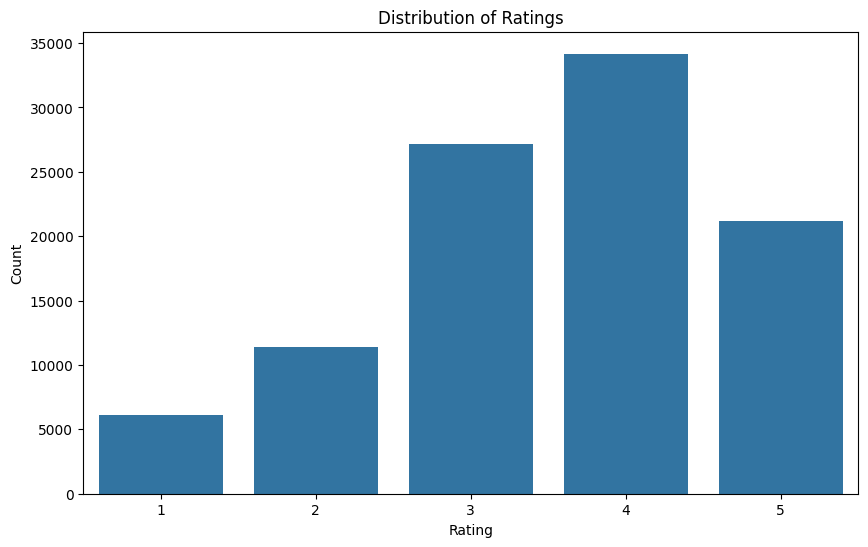

In [ ]:
!wget -nc https://files.grouplens.org/datasets/movielens/ml-100k.zip
!unzip -q -n ml-100k.zip

ratings_df = pd.read_csv('ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])

movies_df = pd.read_csv('ml-100k/u.item', sep='|', encoding='latin-1',
                        names=['item_id', 'title', 'release_date', 'video_release_date',
                               'IMDb_URL', 'unknown', 'Action', 'Adventure', 'Animation',
                               'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
                               'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
                               'Thriller', 'War', 'Western'])

print("Ratings data:")
print(ratings_df.head())

print("\nMovies data:")
print(movies_df[['item_id', 'title']].head())


print(f"\nTotal number of ratings: {len(ratings_df)}")
print(f"Number of unique users: {ratings_df['user_id'].nunique()}")
print(f"Number of unique movies: {ratings_df['item_id'].nunique()}")
print(f"Rating range: {ratings_df['rating'].min()} to {ratings_df['rating'].max()}")
print(f"Average rating: {ratings_df['rating'].mean():.2f}")


plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings_df)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

ratings_df['label'] = (ratings_df['rating'] >= 4).astype(np.float32)

### Data Preparation for NCF
Now, let's prepare the data for our NCF model:

In [ ]:
train_df, test_df = train_test_split(ratings_df, test_size=0.2, random_state=42)

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

num_users = ratings_df['user_id'].max()
num_items = ratings_df['item_id'].max()

print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")

class NCFDataset(Dataset):
    def __init__(self, df):
        self.user_ids = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.item_ids = torch.tensor(df['item_id'].values, dtype=torch.long)
        self.labels = torch.tensor(df['label'].values, dtype=torch.float)

    def __len__(self):
        return len(self.user_ids)

    def __getitem__(self, idx):
        return {
            'user_id': self.user_ids[idx],
            'item_id': self.item_ids[idx],
            'label': self.labels[idx]
        }

train_dataset = NCFDataset(train_df)
test_dataset = NCFDataset(test_df)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Training set size: 80000
Test set size: 20000
Number of users: 943
Number of items: 1682


### Model Architecture
Now we'll implement the Neural Collaborative Filtering (NCF) model, which combines Generalized Matrix Factorization (GMF) and Multi-Layer Perceptron (MLP) components:

In [ ]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32, mlp_layers=[64, 32, 16]):
        super(NCF, self).__init__()

        self.user_embedding_gmf = nn.Embedding(num_users + 1, embedding_dim)
        self.item_embedding_gmf = nn.Embedding(num_items + 1, embedding_dim)

        self.user_embedding_mlp = nn.Embedding(num_users + 1, embedding_dim)
        self.item_embedding_mlp = nn.Embedding(num_items + 1, embedding_dim)

        mlp_input_dim = 2 * embedding_dim
        self.mlp_layers = nn.ModuleList()
        for idx, layer_size in enumerate(mlp_layers):
            if idx == 0:
                self.mlp_layers.append(nn.Linear(mlp_input_dim, layer_size))
            else:
                self.mlp_layers.append(nn.Linear(mlp_layers[idx-1], layer_size))
            self.mlp_layers.append(nn.ReLU())

        self.output_layer = nn.Linear(embedding_dim + mlp_layers[-1], 1)
        self.sigmoid = nn.Sigmoid()

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.01)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user_ids, item_ids):
        user_embedding_gmf = self.user_embedding_gmf(user_ids)
        item_embedding_gmf = self.item_embedding_gmf(item_ids)
        gmf_vector = user_embedding_gmf * item_embedding_gmf

        user_embedding_mlp = self.user_embedding_mlp(user_ids)
        item_embedding_mlp = self.item_embedding_mlp(item_ids)
        mlp_vector = torch.cat([user_embedding_mlp, item_embedding_mlp], dim=-1)

        for layer in self.mlp_layers:
            mlp_vector = layer(mlp_vector)

        concat_vector = torch.cat([gmf_vector, mlp_vector], dim=-1)

        prediction = self.sigmoid(self.output_layer(concat_vector)).squeeze()

        return prediction

embedding_dim = 32
mlp_layers = [64, 32, 16]
model = NCF(num_users, num_items, embedding_dim, mlp_layers).to(device)

print(model)

NCF(
  (user_embedding_gmf): Embedding(944, 32)
  (item_embedding_gmf): Embedding(1683, 32)
  (user_embedding_mlp): Embedding(944, 32)
  (item_embedding_mlp): Embedding(1683, 32)
  (mlp_layers): ModuleList(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=48, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Training the Model
Let's train our NCF model:

Evaluating: 100%|██████████| 79/79 [00:01<00:00, 49.02it/s]


Epoch 1/10 - Train Loss: 0.6059, Val Loss: 0.5664, AUC: 0.7716, AP: 0.7898


Evaluating: 100%|██████████| 79/79 [00:00<00:00, 137.94it/s]


Epoch 2/10 - Train Loss: 0.5483, Val Loss: 0.5562, AUC: 0.7814, AP: 0.7998


Evaluating: 100%|██████████| 79/79 [00:01<00:00, 44.33it/s]


...

Epoch 8/10 - Train Loss: 0.3870, Val Loss: 0.6086, AUC: 0.7666, AP: 0.7842


Evaluating: 100%|██████████| 79/79 [00:00<00:00, 287.39it/s]


Epoch 9/10 - Train Loss: 0.3518, Val Loss: 0.6380, AUC: 0.7597, AP: 0.7780


Evaluating: 100%|██████████| 79/79 [00:00<00:00, 280.39it/s]


Epoch 10/10 - Train Loss: 0.3179, Val Loss: 0.6694, AUC: 0.7547, AP: 0.7725


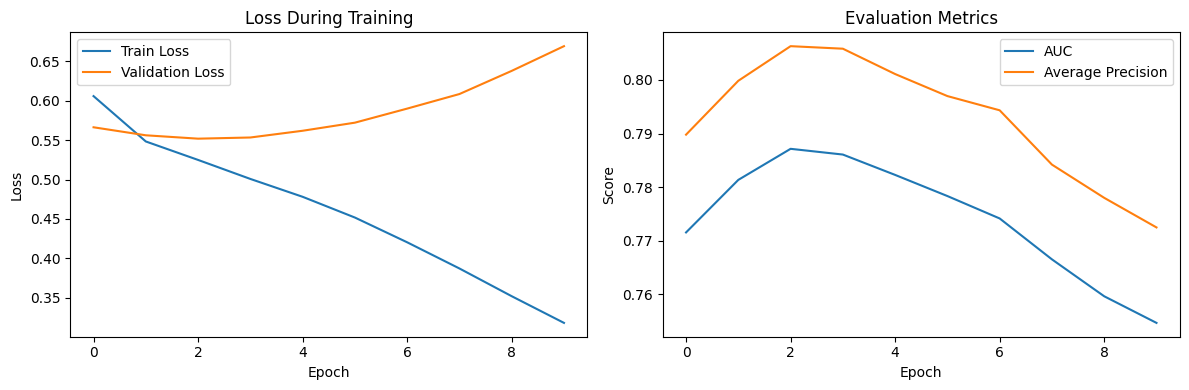

Model saved successfully!


In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

def train_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training"):
        user_ids = batch['user_id'].to(device)
        item_ids = batch['item_id'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(user_ids, item_ids)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(data_loader)

def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            user_ids = batch['user_id'].to(device)
            item_ids = batch['item_id'].to(device)
            labels = batch['label'].to(device)

            outputs = model(user_ids, item_ids)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    from sklearn.metrics import roc_auc_score, average_precision_score
    auc = roc_auc_score(true_labels, predictions)
    ap = average_precision_score(true_labels, predictions)

    return {
        'loss': total_loss / len(data_loader),
        'auc': auc,
        'ap': ap
    }

num_epochs = 10
history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_ap': []}

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)

    eval_metrics = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(eval_metrics['loss'])
    history['val_auc'].append(eval_metrics['auc'])
    history['val_ap'].append(eval_metrics['ap'])

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, "
          f"Val Loss: {eval_metrics['loss']:.4f}, "
          f"AUC: {eval_metrics['auc']:.4f}, "
          f"AP: {eval_metrics['ap']:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_auc'], label='AUC')
plt.plot(history['val_ap'], label='Average Precision')
plt.title('Evaluation Metrics')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()

plt.tight_layout()
plt.show()

torch.save(model.state_dict(), 'ncf_model.pth')
print("Model saved successfully!")

### Generating Recommendations
Now let's create a function to generate recommendations for users:

In [ ]:
def generate_recommendations(model, user_id, n=10):
    model.eval()
    user_ids = torch.tensor([user_id] * num_items, dtype=torch.long).to(device)
    item_ids = torch.tensor(range(1, num_items + 1), dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_ids, item_ids).cpu().numpy()

    items_df = pd.DataFrame({
        'item_id': range(1, num_items + 1),
        'score': predictions
    })

    user_rated_items = set(ratings_df[ratings_df['user_id'] == user_id]['item_id'].values)

    items_df = items_df[~items_df['item_id'].isin(user_rated_items)]

    top_n_items = items_df.sort_values('score', ascending=False).head(n)

    recommendations = pd.merge(top_n_items, movies_df[['item_id', 'title']], on='item_id')

    return recommendations[['item_id', 'title', 'score']]

test_users = [1, 42, 100]

for user_id in test_users:
    print(f"\nTop 10 recommendations for user {user_id}:")
    recommendations = generate_recommendations(model, user_id, n=10)
    print(recommendations)

    print(f"\nMovies that user {user_id} has rated highly (4-5 stars):")
    user_liked = ratings_df[(ratings_df['user_id'] == user_id) & (ratings_df['rating'] >= 4)]
    user_liked = pd.merge(user_liked, movies_df[['item_id', 'title']], on='item_id')
    user_liked[['item_id', 'title', 'rating']]


Top 10 recommendations for user 1:
   item_id                                        title     score
0     1007                   Waiting for Guffman (1996)  0.997280
1      657             Manchurian Candidate, The (1962)  0.995976
2     1169                                 Fresh (1994)  0.995804
3     1202  Maybe, Maybe Not (Bewegte Mann, Der) (1994)  0.992750
4     1367                                 Faust (1994)  0.990508
5     1524                         Kaspar Hauser (1993)  0.989901
6      608                            Spellbound (1945)  0.989596
7     1396                             Stonewall (1995)  0.989359
8     1449                       Pather Panchali (1955)  0.986554
9     1138                              Best Men (1997)  0.985961

Movies that user 1 has rated highly (4-5 stars):

Top 10 recommendations for user 42:
   item_id                                           title     score
0      313                                  Titanic (1997)  0.998716
1     1449   

### Evaluating the Model Further
Let's evaluate our model further by computing some additional metrics:

Evaluating: 100%|██████████| 79/79 [00:00<00:00, 251.14it/s]


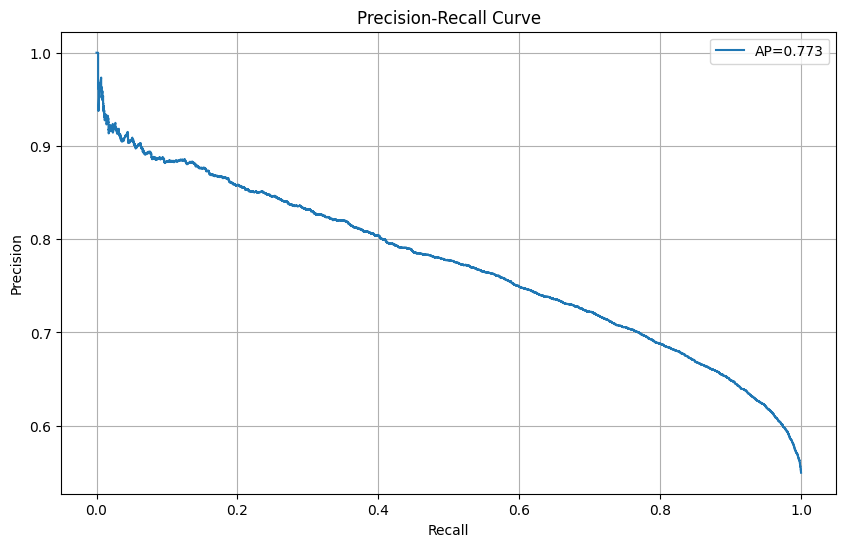

AUC: 0.7547
Average Precision: 0.7725
Accuracy: 0.6888


In [ ]:
def evaluate_model_with_metrics(model, test_loader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            user_ids = batch['user_id'].to(device)
            item_ids = batch['item_id'].to(device)
            labels = batch['label'].to(device)

            outputs = model(user_ids, item_ids)

            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, accuracy_score

    binary_preds = [1 if p >= 0.5 else 0 for p in predictions]

    auc = roc_auc_score(true_labels, predictions)
    ap = average_precision_score(true_labels, predictions)
    accuracy = accuracy_score(true_labels, binary_preds)

    precision, recall, thresholds = precision_recall_curve(true_labels, predictions)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, label=f'AP={ap:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        'auc': auc,
        'ap': ap,
        'accuracy': accuracy
    }

metrics = evaluate_model_with_metrics(model, test_loader, device)
print(f"AUC: {metrics['auc']:.4f}")
print(f"Average Precision: {metrics['ap']:.4f}")
print(f"Accuracy: {metrics['accuracy']:.4f}")

### Cold Start Analysis
Let's analyze how our model performs for new users or users with few ratings (cold start problem):

Number of users in each rating frequency group:
group
11-50     380
100+      361
51-100    202
1-10        0
Name: count, dtype: int64


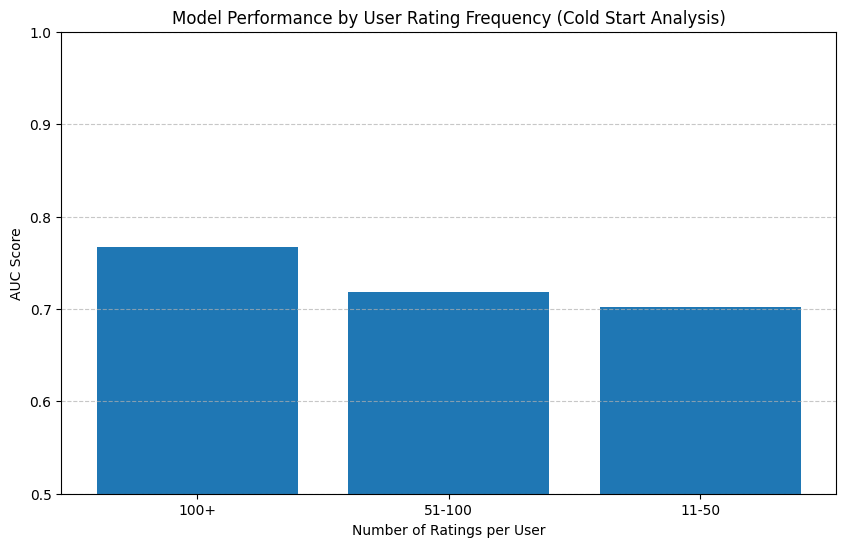

AUC scores by user rating frequency:
100+: 0.7674
51-100: 0.7181
11-50: 0.7018


In [ ]:
user_rating_counts = ratings_df.groupby('user_id').size().reset_index(name='count')
user_rating_counts['group'] = pd.cut(user_rating_counts['count'],
                                    bins=[0, 10, 50, 100, float('inf')],
                                    labels=['1-10', '11-50', '51-100', '100+'])

print("Number of users in each rating frequency group:")
print(user_rating_counts['group'].value_counts())

def evaluate_by_user_group(model, ratings_df, user_groups, device):
    results = {}

    for group_name, user_ids in user_groups.items():
        group_ratings = ratings_df[ratings_df['user_id'].isin(user_ids)]

        group_dataset = NCFDataset(group_ratings)
        group_loader = DataLoader(group_dataset, batch_size=256, shuffle=False)

        if len(group_loader) == 0:
            continue

        model.eval()
        predictions = []
        true_labels = []

        with torch.no_grad():
            for batch in group_loader:
                user_ids = batch['user_id'].to(device)
                item_ids = batch['item_id'].to(device)
                labels = batch['label'].to(device)

                outputs = model(user_ids, item_ids)

                predictions.extend(outputs.cpu().numpy())
                true_labels.extend(labels.cpu().numpy())

        from sklearn.metrics import roc_auc_score
        try:
            auc = roc_auc_score(true_labels, predictions)
            results[group_name] = auc
        except:
            results[group_name] = None

    return results

user_groups = {}
for group in user_rating_counts['group'].unique():
    users_in_group = user_rating_counts[user_rating_counts['group'] == group]['user_id'].values
    user_groups[group] = users_in_group

group_performance = evaluate_by_user_group(model, test_df, user_groups, device)

plt.figure(figsize=(10, 6))
groups = []
aucs = []

for group, auc in group_performance.items():
    if auc is not None:
        groups.append(group)
        aucs.append(auc)

plt.bar(groups, aucs)
plt.xlabel('Number of Ratings per User')
plt.ylabel('AUC Score')
plt.title('Model Performance by User Rating Frequency (Cold Start Analysis)')
plt.ylim(0.5, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("AUC scores by user rating frequency:")
for group, auc in group_performance.items():
    if auc is not None:
        print(f"{group}: {auc:.4f}")

### Business Insights and Extensions


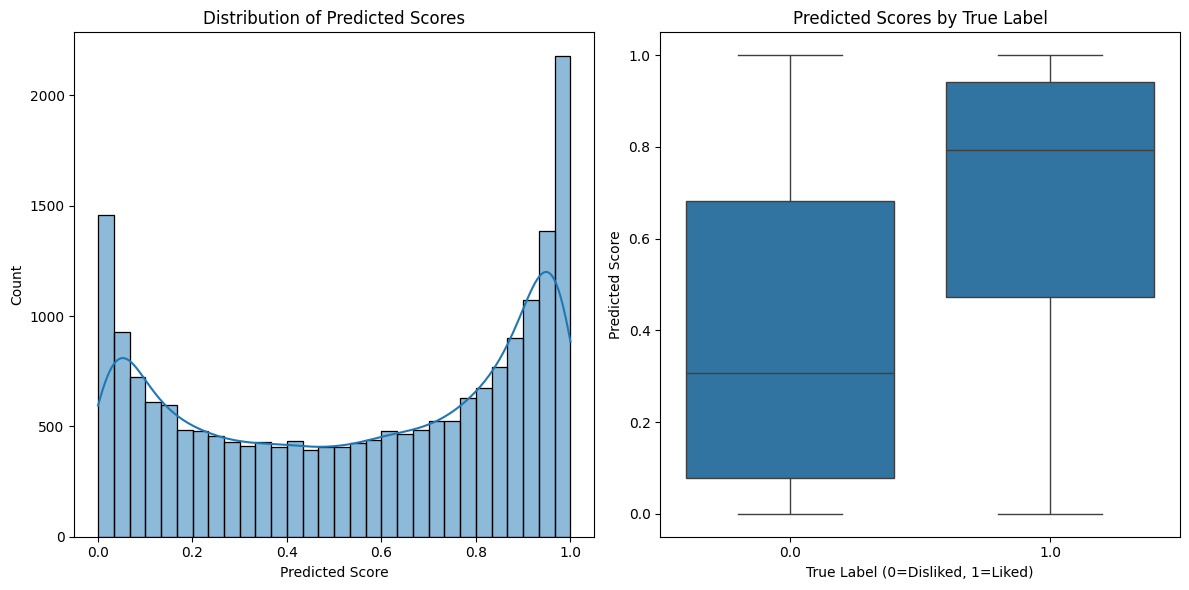

Average prediction scores:
Items user disliked (0): 0.3869
Items user liked (1): 0.6872


In [ ]:
def analyze_predictions(model, data_loader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in data_loader:
            user_ids = batch['user_id'].to(device)
            item_ids = batch['item_id'].to(device)
            labels = batch['label'].to(device)

            outputs = model(user_ids, item_ids)

            predictions.extend(outputs.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    results_df = pd.DataFrame({
        'true_label': true_labels,
        'predicted_score': predictions
    })

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(results_df['predicted_score'], bins=30, kde=True)
    plt.title('Distribution of Predicted Scores')
    plt.xlabel('Predicted Score')
    plt.ylabel('Count')

    plt.subplot(1, 2, 2)
    sns.boxplot(x='true_label', y='predicted_score', data=results_df)
    plt.title('Predicted Scores by True Label')
    plt.xlabel('True Label (0=Disliked, 1=Liked)')
    plt.ylabel('Predicted Score')

    plt.tight_layout()
    plt.show()

    avg_scores = results_df.groupby('true_label')['predicted_score'].mean()
    print("Average prediction scores:")
    print(f"Items user disliked (0): {avg_scores[0]:.4f}")
    print(f"Items user liked (1): {avg_scores[1]:.4f}")

analyze_predictions(model, test_loader, device)